<a href="https://colab.research.google.com/github/bautistabc/AI_llama/blob/master/comandero_alumno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ### 🔓 ¿Te atoras en algún 👉 TU TURNO?
> Abre la **versión RESUELTA** que te compartió tu profe. 👉 _[ link de la solución ]_

# 🧾 PROYECTO FINAL · EL COMANDERO — el mesero de WhatsApp de Chida Café ☕

Vas a construir un **mesero automático de WhatsApp** que junta **TODO** lo del curso:

| Paso | Concepto del curso | Qué hace en El Comandero |
|---|---|---|
| ① | **Fine-tuning** (DistilBERT + LoRA) | Lee el mensaje y decide qué es: **PEDIDO / PREGUNTA / QUEJA / OTRO** |
| ② | **RAG** (sentence-transformers) | Busca el **dato real** en el menú (precio, horario, si hay leche de avena…) |
| ③ | **Prompt** (Groq · gpt-oss-20b) | **Redacta** la respuesta con voz de mesero buena onda |
| ④ | **Evaluación** (matriz + Groq-juez) | Mide **qué tan bien** clasificó y si **citó bien** el menú |

> 🧠 **La idea clave:** el clasificador decide **quién contesta**. PEDIDO y PREGUNTA → los atiende la IA (con el dato real). QUEJA y OTRO → **se pasan a un humano** (la IA no inventa ni improvisa en lo delicado).

### 🗺️ El plan (a botones)
`Instalar → Llave de Groq → Menú → RAG → Dataset → Clasificador (antes) → LoRA + Entrenar → (después + matriz) → Voz del mesero → Juez → App Gradio`

> ✅ Corre en **CPU**. La única llave es **GROQ_API_KEY** (gratis en groq.com).

Busca los **👉 TU TURNO** (mensajes que TÚ escribes). Corre cada celda con **▶** en orden. 🚀

## 🔧 Paso 1 · Instalar las herramientas
Un solo `pip` baja todo: Hugging Face (entrenar + clasificar), sentence-transformers (RAG), Groq (redactar) y Gradio (la app).

In [ ]:
%%capture
# torchao de Colab a veces choca con peft → lo quitamos para evitar el error
!pip uninstall -y torchao
!pip install -q transformers peft datasets sentence-transformers groq "gradio>=6,<7"

## 🔑 Paso 2 · Pega tu llave de Groq
Groq es el **cerebro que redacta** las respuestas. Saca tu llave gratis en **groq.com → API Keys** y pégala cuando te la pida (no se guarda en el notebook).

> 🧠 **Quién hace qué:** Groq **redacta**. El **dato** (precio, horario) lo busca el **RAG** local del Paso 4 — eso es gratis y no usa internet de Groq.

In [ ]:
import os, time
from getpass import getpass
from groq import Groq

os.environ["GROQ_API_KEY"] = getpass("🔑 Pega tu GROQ_API_KEY y dale Enter: ")
groq_client = Groq(api_key="SU_APIKEY")
GROQ_MODEL = "openai/gpt-oss-20b"   # modelo abierto, el mismo de la Clase 2

def preguntar_a_groq(prompt, temperatura=0.4):
    """Manda un prompt a Groq y regresa el texto. Si el plan gratis te frena, espera y reintenta una vez."""
    for intento in (1, 2):
        try:
            r = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperatura,
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            if intento == 1:
                print("⏳ Groq se tardó o te frenó; espero 5 seg y reintento…")
                time.sleep(5)
            else:
                return f"(No pude contestar: {type(e).__name__}. Revisa tu llave o espera un minuto.)"

print("Groq listo ✅  ·  modelo:", GROQ_MODEL)

🔑 Pega tu GROQ_API_KEY y dale Enter: ··········
Groq listo ✅  ·  modelo: openai/gpt-oss-20b


## 📋 Paso 3 · El menú de Chida Café (los datos del negocio)
Este texto es **la única verdad** del mesero: precios, horarios, promos, wifi, envíos. El mesero **jamás** inventará algo que no esté aquí.

In [ ]:
MENU = """CHIDA CAFÉ ☕ — Datos del negocio

== UBICACIÓN ==
Chida Café está en Av. de los Insurgentes 245, Col. Roma Norte, CDMX.
Referencia: a media cuadra del metro Insurgentes, junto a la farmacia azul.
Teléfono y WhatsApp: 55 1234 5678.
Instagram: @chidacafe.

== HORARIOS ==
Lunes a viernes abrimos de 7:00 a 21:00.
Sábados abrimos de 8:00 a 22:00.
Domingos abrimos de 9:00 a 18:00.
La cocina caliente (molletes, chilaquiles, sándwiches) cierra 30 minutos antes del cierre.

== MENÚ DE CAFÉ CALIENTE ==
Café americano: $38 chico, $45 grande.
Espresso sencillo: $35.
Espresso doble: $45.
Capuchino: $52.
Latte: $55.
Latte de vainilla o caramelo: $60.
Mocha (chocolate): $62.
Chocolate caliente: $50.
Té (manzanilla, verde, menta): $40.

== MENÚ DE CAFÉ FRÍO ==
Café frío (cold brew): $58.
Frappé de café: $65.
Frappé de mocha o caramelo: $70.
Matcha latte frío: $68.

== LECHES ALTERNATIVAS ==
Cambio a leche de almendra, avena o soya: +$12 en cualquier bebida.

== PANADERÍA Y POSTRES ==
Concha (chocolate o vainilla): $22.
Croissant natural: $30.
Croissant relleno de jamón y queso: $48.
Rebanada de pastel de zanahoria: $58.
Galleta de chispas de chocolate: $28.
Muffin de arándano: $35.

== COMIDA ==
Molletes (2 piezas con frijol, queso y pico de gallo): $75.
Chilaquiles verdes o rojos con huevo: $95.
Sándwich de pavo con papas: $89.
Bagel con queso crema y salmón: $110.
Avena con fruta y miel: $55.

== PROMOS ==
Promo mañanera: de 7:00 a 10:00, café americano grande + concha por $55.
Martes 2x1 en frappés (solo consumo en tienda).
Tarjeta de sellos: junta 9 cafés y el número 10 va gratis.
Estudiantes con credencial vigente: 15% de descuento de lunes a viernes.

== FORMAS DE PAGO ==
Aceptamos efectivo.
Aceptamos tarjeta de crédito y débito (Visa, Mastercard, American Express).
Aceptamos pagos con transferencia (SPEI) y con código QR (Mercado Pago).
No manejamos vales de despensa.

== WIFI ==
Sí hay wifi gratis para clientes.
Red: ChidaCafe_Clientes.
Contraseña del wifi: cafecito2026.

== ENVÍOS A DOMICILIO ==
Hacemos envíos por Uber Eats, Rappi y DiDi Food.
También entregamos directo por WhatsApp en la Col. Roma Norte y Roma Sur.
Envío directo por WhatsApp: costo $35, gratis en pedidos mayores a $250.
El tiempo estimado de entrega directa es de 30 a 45 minutos.
El pedido mínimo para envío directo es de $120."""

print("Menú cargado ✅ ·", len(MENU), "caracteres")

Menú cargado ✅ · 2328 caracteres


## 🔎 Paso 4 · RAG — hacer el menú *buscable*
Partimos el menú en **secciones** (Horarios, Precios, Wifi, Envíos…) y las convertimos en **embeddings** (numeritos) para poder buscar por significado, no por palabra exacta.

> 🧠 **Concepto → RAG:** `buscar()` toma la pregunta del cliente y regresa las **secciones más parecidas**. Así el mesero contesta con el dato real.

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Cortamos el menú por secciones (cada bloque "== TÍTULO ==" con sus líneas)
def trocear(texto):
    chunks, actual = [], []
    for linea in texto.split("\n"):
        if linea.startswith("== ") and linea.endswith(" =="):
            if actual: chunks.append("\n".join(actual).strip())
            actual = [linea]
        else:
            actual.append(linea)
    if actual: chunks.append("\n".join(actual).strip())
    return [c for c in chunks if c]

secciones = trocear(MENU)

# Modelo de embeddings MULTILINGÜE (entiende español)
buscador = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb_secciones = buscador.encode(secciones, convert_to_tensor=True)

def buscar(pregunta, k=3):
    """Regresa las k secciones del menú más parecidas a la pregunta."""
    emb_q = buscador.encode(pregunta, convert_to_tensor=True)
    hits = util.semantic_search(emb_q, emb_secciones, top_k=k)[0]
    return [secciones[h["corpus_id"]] for h in hits]

print(len(secciones), "secciones listas para buscar ✅")
print("\nEjemplo — busco '¿tienen wifi?':\n")
print(buscar("¿tienen wifi?", k=1)[0])

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

12 secciones listas para buscar ✅

Ejemplo — busco '¿tienen wifi?':

== WIFI ==
Sí hay wifi gratis para clientes.
Red: ChidaCafe_Clientes.
Contraseña del wifi: cafecito2026.


## 🎨 Paso 5 · El dataset de mensajes (4 clases)
Mensajes de WhatsApp con su etiqueta: **PEDIDO / PREGUNTA / QUEJA / OTRO**. Y un set de **prueba** aparte (el modelo NO lo ve al entrenar) para medir de verdad.

> ### ✋ AQUÍ TE TOCA A TI (2 renglones)
> En la celda de abajo hay **2 renglones que dicen `👉 TU TURNO`**. Borra ese texto y escribe TÚ el mensaje **entre las comillas**.
> ⚠️ No cambies la etiqueta de la derecha (`"PEDIDO"`, `"QUEJA"`) ni borres las comillas ni la coma del final.

In [ ]:
from datasets import Dataset

CLASES = ['PEDIDO', 'PREGUNTA', 'QUEJA', 'OTRO']
clase2id = {c: i for i, c in enumerate(CLASES)}
id2clase = {i: c for i, c in enumerate(CLASES)}

mensajes = [
    ('Me das un capuchino grande porfa ☕', 'PEDIDO'),
    ('Quiero 2 lattes y una rebanada de pastel de zanahoria', 'PEDIDO'),
    ('Buenas, me mandas un americano para llevar', 'PEDIDO'),
    ('Kiero un frappé de mocha y unas galletas 🍪', 'PEDIDO'),
    ("👉 TU TURNO: escribe un mensaje de PEDIDO de un cliente", "PEDIDO"),
    ('Ocupo 3 capuchinos para la ofi, ¿se puede?', 'PEDIDO'),
    ('¿A qué hora abren mañana?', 'PREGUNTA'),
    ('¿Cuánto cuesta el latte grande?', 'PREGUNTA'),
    ('¿Tienen leche de almendra?', 'PREGUNTA'),
    ('¿Puedo pagar con tarjeta de crédito? 🤔', 'PREGUNTA'),
    ('¿Qué precio tiene el pastel de zanahoria?', 'PREGUNTA'),
    ('¿Están abiertos los domingos?', 'PREGUNTA'),
    ('Mi café llegó frío otra vez 😡', 'QUEJA'),
    ('Pedí sin azúcar y me lo trajeron dulcísimo', 'QUEJA'),
    ('Llevo 30 min esperando y nada, pésimo servicio', 'QUEJA'),
    ('El pan estaba bien duro, qué mal', 'QUEJA'),
    ('Me cobraron de más, no es justo', 'QUEJA'),
    ("👉 TU TURNO: escribe una QUEJA de un cliente enojado", "QUEJA"),
    ('Holaa buenas tardes 👋', 'OTRO'),
    ('¡Muchas gracias, todo bien rico!', 'OTRO'),
    ('Ganaste un premio, haz click aquí www.premio-gratis.com', 'OTRO'),
    ('Feliz cumple a todo el equipo 🎉', 'OTRO'),
    ('¡Qué padre la foto que subieron al insta! 📸', 'OTRO'),
    ('No gracias, luego me doy la vuelta', 'OTRO'),
    ('jajaja me encantó su historia de ayer en redes ❤️', 'OTRO'),
    ('Están bien chidas sus fotos, saludos 😄', 'OTRO'),
]

# Mensajes de PRUEBA (held-out): NO están en el entrenamiento
PRUEBA = [
    ('Me preparas un chocolate caliente porfis', 'PEDIDO'),
    ('Quiero una malteada de fresa para llevar 🍓', 'PEDIDO'),
    ('¿Aceptan tarjeta o solo efectivo?', 'PREGUNTA'),
    ('¿Cuánto sale el combo de desayuno?', 'PREGUNTA'),
    ('Me dieron mal mi orden, esto no es lo que pedí 😤', 'QUEJA'),
    ('El lugar estaba bien sucio, muy decepcionada', 'QUEJA'),
    ('¡Buenos días! 😊', 'OTRO'),
    ('Nel, gracias, solo preguntaba', 'OTRO'),
]

train_ds = Dataset.from_dict({
    "text":   [t for t, c in mensajes],
    "labels": [clase2id[c] for t, c in mensajes],
})
print(len(mensajes), "mensajes de entrenamiento y", len(PRUEBA), "de prueba ✅")
print("Clases:", CLASES)

26 mensajes de entrenamiento y 8 de prueba ✅
Clases: ['PEDIDO', 'PREGUNTA', 'QUEJA', 'OTRO']


## 🅰️ Paso 6 · El clasificador ANTES de afinar
Cargamos **DistilBERT multilingüe** con una "cabecita" de 4 opciones. Como está **sin entrenar**, va a adivinar (aciertos bajitos).

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, logging
logging.set_verbosity_error()

nombre = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(nombre)
modelo = AutoModelForSequenceClassification.from_pretrained(
    nombre, num_labels=4, id2label=id2clase, label2id=clase2id)

def tok(b): return tokenizer(b["text"], truncation=True, padding="max_length", max_length=64)
train_tok = train_ds.map(tok, batched=True)

def clasificar(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, max_length=64).to(modelo.device)
    modelo.eval()
    with torch.no_grad():
        logits = modelo(**inputs).logits
    return id2clase[int(logits.argmax(dim=-1))]

def aciertos():
    return round(100 * sum(clasificar(t) == c for t, c in PRUEBA) / len(PRUEBA))

antes_pred = {t: clasificar(t) for t, c in PRUEBA}
antes_acc = aciertos()
print("Aciertos ANTES:", antes_acc, "%  (adivinando, como debe ser)")

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Map:   0%|          | 0/26 [00:00<?, ? examples/s]

Aciertos ANTES: 12 %  (adivinando, como debe ser)


## 🧩 Paso 7 · Ponle LoRA y entrena
LoRA entrena solo unas "perillas nuevas" + la cabecita (menos del 1% del modelo). Barato, rápido y estable.

In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer

config_lora = LoraConfig(
    task_type="SEQ_CLS", r=8, lora_alpha=16,
    target_modules=["q_lin", "v_lin"], lora_dropout=0.05,
    modules_to_save=["pre_classifier", "classifier"],  # ¡entrena también la cabecita!
)
modelo = get_peft_model(modelo, config_lora)
modelo.print_trainable_parameters()

args = TrainingArguments(
    output_dir="/content/comandero", num_train_epochs=40,
    per_device_train_batch_size=4, learning_rate=5e-4,
    logging_steps=10, report_to="none",
)
trainer = Trainer(model=modelo, args=args, train_dataset=train_tok)
trainer.train()
print("¡Entrenado! 🎉")

trainable params: 741,124 || all params: 136,068,872 || trainable%: 0.5447


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.357', 'grad_norm': '2.634', 'learning_rate': '0.0004839', 'epoch': '1.429'}
{'loss': '1.163', 'grad_norm': '3.377', 'learning_rate': '0.0004661', 'epoch': '2.857'}
{'loss': '0.6664', 'grad_norm': '2.115', 'learning_rate': '0.0004482', 'epoch': '4.286'}
{'loss': '0.5339', 'grad_norm': '3.235', 'learning_rate': '0.0004304', 'epoch': '5.714'}
{'loss': '0.2227', 'grad_norm': '1.767', 'learning_rate': '0.0004125', 'epoch': '7.143'}
{'loss': '0.08781', 'grad_norm': '3.172', 'learning_rate': '0.0003946', 'epoch': '8.571'}
{'loss': '0.04318', 'grad_norm': '0.5821', 'learning_rate': '0.0003768', 'epoch': '10'}
{'loss': '0.005029', 'grad_norm': '0.04291', 'learning_rate': '0.0003589', 'epoch': '11.43'}
{'loss': '0.002783', 'grad_norm': '0.009239', 'learning_rate': '0.0003411', 'epoch': '12.86'}
{'loss': '0.00587', 'grad_norm': '0.09922', 'learning_rate': '0.0003232', 'epoch': '14.29'}
{'loss': '0.00533', 'grad_norm': '0.02887', 'learning_rate': '0.0003054', 'epoch': '15.71'}
{'loss':

## 🅱️ Paso 8 · DESPUÉS de afinar + la matriz de confusión (el momento 🤯)
Los **mismos** mensajes de prueba, ahora con el modelo afinado. Y una **matriz de confusión**: qué clase le atinó y en cuál se confundió.

Aciertos ANTES : 12 %
Aciertos DESPUÉS: 75 %

✅ [PEDIDO] (real: PEDIDO)  Me preparas un chocolate caliente porfis
✅ [PEDIDO] (real: PEDIDO)  Quiero una malteada de fresa para llevar 🍓
✅ [PREGUNTA] (real: PREGUNTA)  ¿Aceptan tarjeta o solo efectivo?
✅ [PREGUNTA] (real: PREGUNTA)  ¿Cuánto sale el combo de desayuno?
❌ [OTRO] (real: QUEJA)  Me dieron mal mi orden, esto no es lo que pedí 😤
✅ [QUEJA] (real: QUEJA)  El lugar estaba bien sucio, muy decepcionada
✅ [OTRO] (real: OTRO)  ¡Buenos días! 😊
❌ [QUEJA] (real: OTRO)  Nel, gracias, solo preguntaba


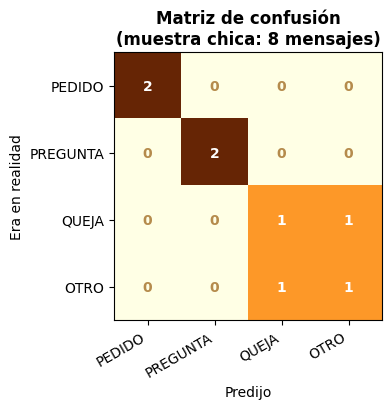


🏁 De 12% a 75% de aciertos con solo afinar. ✅


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

despues_pred = {t: clasificar(t) for t, c in PRUEBA}
despues_acc = aciertos()
print("Aciertos ANTES :", antes_acc, "%")
print("Aciertos DESPUÉS:", despues_acc, "%\n")

for t, c in PRUEBA:
    d = despues_pred[t]
    print(("✅" if d == c else "❌"), f"[{d}] (real: {c})  {t}")

# --- Matriz de confusión (muestra chica: 8 mensajes de prueba) ---
def matriz_confusion():
    M = np.zeros((4, 4), dtype=int)
    for t, c in PRUEBA:
        M[clase2id[c]][clase2id[despues_pred[t]]] += 1
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ax.imshow(M, cmap="YlOrBr")
    ax.set_xticks(range(4)); ax.set_xticklabels(CLASES, rotation=30, ha="right")
    ax.set_yticks(range(4)); ax.set_yticklabels(CLASES)
    ax.set_xlabel("Predijo"); ax.set_ylabel("Era en realidad")
    ax.set_title("Matriz de confusión\n(muestra chica: 8 mensajes)", weight="bold")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, M[i][j], ha="center", va="center",
                    color="white" if M[i][j] else "#b58b4c", weight="bold")
    fig.tight_layout()
    return fig

fig_matriz = matriz_confusion()
fig_matriz.savefig("/content/matriz.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\n🏁 De {antes_acc}% a {despues_acc}% de aciertos con solo afinar. ✅")

## 🗣️ Paso 9 · La voz del mesero (Prompt) + el pipeline completo
Aquí se junta todo: el clasificador decide **quién contesta**. Si es PEDIDO/PREGUNTA, el RAG busca el dato y **Groq redacta** con voz de mesero. Si es QUEJA/OTRO, **se pasa a un humano**.

In [ ]:
SYSTEM_RESPUESTA = """Eres "El Comandero", el mesero de WhatsApp de Chida Café ☕, una cafetería mexicana. Tu chamba es responderle al cliente de forma breve, clara y bien buena onda.

REGLA DE ORO — SOLO EL CONTEXTO:
- Responde ÚNICAMENTE con la información del CONTEXTO del menú que se te entrega abajo. Es tu única fuente de verdad.
- NUNCA inventes precios, productos, horarios, promociones ni disponibilidad. Si un dato no está en el contexto, NO lo adivines.
- Si el cliente pregunta algo que NO viene en el contexto, dilo con honestidad y ofrécete a checarlo con alguien del equipo. Ejemplo: "Uy, ese dato no lo tengo a la mano, pero con gusto te lo confirma alguien del equipo 😊".
- Si el cliente hace un PEDIDO, confírmalo con lo que sí exista en el contexto (producto y precio tal cual aparecen).

VOZ DE MARCA (cómo hablas):
- Cálido, cercano y de tú, como mesero de barrio. Español mexicano suave ("claro que sí", "con gusto", "va", "sale"). Sin "vos/dale/che" ni groserías.
- Breve: 1 a 3 frases. Nada de choro.
- 1 o 2 emojis por mensaje (☕ 😊 🧾 👍), sin exagerar.
- Cierra SIEMPRE ofreciendo ayuda o antojando algo ("¿Se te antoja algo más? 😊").

Usa exactamente los nombres y precios que trae el CONTEXTO. No agregues información de fuera. Responde solo con el mensaje para el cliente, sin explicar tu razonamiento.

CONTEXTO DEL MENÚ:
{contexto}

MENSAJE DEL CLIENTE:
{mensaje}"""

def responder_mesero(mensaje, contexto):
    """Groq redacta la respuesta usando SOLO el contexto del menú."""
    prompt = SYSTEM_RESPUESTA.replace("{contexto}", contexto).replace("{mensaje}", mensaje)
    return preguntar_a_groq(prompt, temperatura=0.4)

def atender(mensaje):
    """Pipeline completo. Regresa un dict con todo lo que pasó."""
    clase = clasificar(mensaje)
    if clase in ("QUEJA", "OTRO"):
        return {"clase": clase, "a_humano": True, "respuesta": None, "contexto": None}
    contexto = "\n\n".join(buscar(mensaje, k=3))          # RAG: top-3 secciones
    respuesta = responder_mesero(mensaje, contexto)        # Prompt: Groq redacta
    return {"clase": clase, "a_humano": False, "respuesta": respuesta, "contexto": contexto}

# Probamos con 2 mensajes del set de PRUEBA (el modelo NO los vio al entrenar):
for m, clase_real in [PRUEBA[2], PRUEBA[4]]:
    r = atender(m)
    print("💬", m)
    if r["a_humano"]:
        print("   →", r["clase"], "· 🙋 pasa a un humano\n")
    else:
        print("   →", r["clase"], "· 🧾", r["respuesta"], "\n")

⏳ Groq se tardó o te frenó; espero 5 seg y reintento…
💬 ¿Aceptan tarjeta o solo efectivo?
   → PREGUNTA · 🧾 (No pude contestar: AuthenticationError. Revisa tu llave o espera un minuto.) 

💬 Me dieron mal mi orden, esto no es lo que pedí 😤
   → OTRO · 🙋 pasa a un humano



## 🧑‍⚖️ Paso 10 · El juez (Groq evalúa a Groq)
Otra vuelta de evaluación: el mesero responde y **otro Groq de juez** califica si **citó bien el menú** (1–5) y si el **tono** es de Chida Café. Al juez le damos también la **respuesta correcta**, para que pueda cachar cuando el mesero se equivocó de dato.

> ⚠️ **Tier gratis de Groq:** usamos **3 preguntas** (son 6 llamadas) para no toparnos con el límite.

In [ ]:
import json as _json

PROMPT_JUEZ = """Eres un juez de calidad para "El Comandero", el mesero de WhatsApp de Chida Café ☕. Vas a calificar QUÉ TAN BIEN respondió el mesero, comparando su respuesta contra el dato real del menú.

Recibes tres cosas:
- PREGUNTA DEL CLIENTE: {pregunta}
- CONTEXTO DEL MENÚ (la verdad, la única fuente válida): {contexto}
- RESPUESTA DEL COMANDERO (lo que hay que calificar): {respuesta}

Califica DOS cosas, cada una del 1 al 5 (1 = pésimo, 5 = excelente):

1) uso_menu — ¿La respuesta usó bien el dato del CONTEXTO?
   - 5: usó el dato correcto (precio/producto/horario) exacto como en el contexto, sin inventar nada.
   - 3: parcialmente correcto o incompleto.
   - 1: inventó datos, se contradijo con el contexto o dio info falsa.
   - Si el dato NO estaba en el contexto y el mesero lo reconoció con honestidad (en vez de inventar), eso cuenta como bueno (4-5).

2) tono — ¿Sonó a Chida Café? (cálido, mexicano suave, breve, con 1-2 emojis, y cerró ofreciendo ayuda).
   - 5: cumple todo. 3: le falta algo (muy seco, sin cierre, o demasiado largo). 1: frío, robótico o fuera de marca.

Devuelve ÚNICAMENTE un JSON válido, sin texto extra antes ni después, con esta forma exacta:
{
  "uso_menu": <1-5>,
  "tono": <1-5>,
  "cito_dato_correcto": <true|false>,
  "comentario": "<una frase corta en español mexicano explicando la calificación>"
}

DATO CORRECTO SEGÚN EL MENÚ (úsalo para verificar si el mesero acertó): {esperada}"""
PREGUNTAS_JUEZ = [
    {'pregunta': '¿A qué hora abren los domingos?', 'esperada': 'Los domingos Chida Café abre de 9:00 a 18:00.'},
    {'pregunta': '¿Cuánto cuesta un capuchino?', 'esperada': 'El capuchino cuesta $52.'},
    {'pregunta': '¿Tienen wifi y cuál es la contraseña?', 'esperada': 'Sí hay wifi gratis para clientes; la red es ChidaCafe_Clientes y la contraseña es cafecito2026.'},
]

def juzgar(pregunta, contexto, respuesta, esperada=""):
    prompt = (PROMPT_JUEZ.replace("{pregunta}", pregunta)
                         .replace("{contexto}", contexto)
                         .replace("{respuesta}", respuesta)
                         .replace("{esperada}", esperada))
    crudo = preguntar_a_groq(prompt, temperatura=0.0)
    try:
        ini, fin = crudo.find("{"), crudo.rfind("}")
        return _json.loads(crudo[ini:fin+1])
    except Exception:
        return {"uso_menu": None, "tono": None, "cito_dato_correcto": None, "comentario": crudo[:120]}

resultados_juez = []
for item in PREGUNTAS_JUEZ:
    ctx = "\n\n".join(buscar(item["pregunta"], k=3))
    resp = responder_mesero(item["pregunta"], ctx)
    v = juzgar(item["pregunta"], ctx, resp, item["esperada"])
    resultados_juez.append({"pregunta": item["pregunta"], "respuesta": resp, **v})
    print("❓", item["pregunta"])
    print("   🧾", resp)
    print("   🧑‍⚖️ uso_menu:", v.get("uso_menu"), "· tono:", v.get("tono"), "·", v.get("comentario"), "\n")

_notas = [r["uso_menu"] for r in resultados_juez if isinstance(r.get("uso_menu"), (int, float))]
promedio_menu = round(sum(_notas) / len(_notas), 1) if _notas else None
print("⭐ Promedio 'uso del menú':", promedio_menu, "/ 5")

⏳ Groq se tardó o te frenó; espero 5 seg y reintento…
⏳ Groq se tardó o te frenó; espero 5 seg y reintento…
❓ ¿A qué hora abren los domingos?
   🧾 (No pude contestar: AuthenticationError. Revisa tu llave o espera un minuto.)
   🧑‍⚖️ uso_menu: None · tono: None · (No pude contestar: AuthenticationError. Revisa tu llave o espera un minuto.) 

⏳ Groq se tardó o te frenó; espero 5 seg y reintento…
⏳ Groq se tardó o te frenó; espero 5 seg y reintento…
❓ ¿Cuánto cuesta un capuchino?
   🧾 (No pude contestar: AuthenticationError. Revisa tu llave o espera un minuto.)
   🧑‍⚖️ uso_menu: None · tono: None · (No pude contestar: AuthenticationError. Revisa tu llave o espera un minuto.) 

⏳ Groq se tardó o te frenó; espero 5 seg y reintento…
⏳ Groq se tardó o te frenó; espero 5 seg y reintento…
❓ ¿Tienen wifi y cuál es la contraseña?
   🧾 (No pude contestar: AuthenticationError. Revisa tu llave o espera un minuto.)
   🧑‍⚖️ uso_menu: None · tono: None · (No pude contestar: AuthenticationError. Revisa 

## ☕ Paso 11 · La app de Gradio (El Comandero en vivo)
La ventanita bonita: pega un mensaje de cliente y ve en vivo cómo clasifica, busca y contesta — más la pestaña de evaluación. Al correr, Colab te da un **link público** (`share=True`).

In [ ]:
import os
import gradio as gr

EMOJI = {"PEDIDO":"🧾","PREGUNTA":"❓","QUEJA":"😕","OTRO":"💬"}
COLOR = {"PEDIDO":"#6F8F5E","PREGUNTA":"#C98A3B","QUEJA":"#C0562F","OTRO":"#8A7A6D"}
EJEMPLOS_UI = [
    'Hola! Me das un capuchino grande y una concha de chocolate para llevar, porfa 🙏',
    '¿A qué hora abren los domingos? ¿Y tienen leche de avena?',
    'Oigan, mi café llegó frío y esperé como 20 minutos, muy mal servicio 😤',
    'jajaja qué chida la foto que subieron ayer al insta ❤️',
    '¿Cuánto cuesta el latte de vainilla? ¿y tienen wifi?',
    '¿Venden malteada de fresa?',
]

def badge_html(clase):
    c = COLOR[clase]
    return (f'<div style="display:inline-block;padding:8px 18px;border-radius:999px;'
            f'background:{c};color:#fff;font-weight:800;font-size:18px;'
            f'box-shadow:0 3px 10px {c}55;">{EMOJI[clase]} {clase}</div>')

HUMANO_HTML = ('<div style="background:#F7E6DF;border:2px solid #C0562F;border-radius:16px;'
               'padding:18px 20px;color:#7a2e18;font-size:16px;">🙋 <b>Esto se lo paso a un '
               'humano del equipo</b> — un compa te contesta en un momento. 🤎</div>')

# Lo que se ve ANTES de la primera orden (si no, la tarjeta se ve vacía y parece rota)
ESPERANDO = ('<div style="padding:22px 18px;color:#A67B5B;font-size:16px;text-align:center;">'
             '☕ Escribe un mensaje del cliente (o pica un ejemplo) y dale a '
             '<b>Tomar la orden</b>.<br>Aquí te digo qué tipo de mensaje es y qué contestar.</div>')

def clasificar_con_probs(mensaje):
    inputs = tokenizer(mensaje, return_tensors="pt", truncation=True, max_length=64).to(modelo.device)
    modelo.eval()
    with torch.no_grad():
        probs = modelo(**inputs).logits.softmax(dim=-1)[0]
    dic = {id2clase[i]: float(probs[i]) for i in range(4)}
    clase = max(dic, key=dic.get)
    return clase, dic

def ui_atender(mensaje):
    if not mensaje or not mensaje.strip():
        return (ESPERANDO, gr.update(value={}, visible=False), "",
                gr.update(visible=False), gr.update(value="", visible=False))
    clase, probs = clasificar_con_probs(mensaje)
    badge = badge_html(clase)
    if clase in ("QUEJA", "OTRO"):
        return (badge, gr.update(value=probs, visible=True), "",
                gr.update(value=HUMANO_HTML, visible=True), gr.update(value="", visible=False))
    contexto = "\n\n".join(buscar(mensaje, k=3))
    respuesta = responder_mesero(mensaje, contexto)
    return (badge, gr.update(value=probs, visible=True), f"### 🧾 El Comandero dice:\n{respuesta}",
            gr.update(visible=False), gr.update(value=contexto, visible=True))

# --- Resumen del juez (usa lo calculado en el Paso 10) ---
try:
    _verdicto = (f"**⭐ Uso del menú:** {promedio_menu} / 5 en {len(resultados_juez)} preguntas de prueba.  \n"
                 f"El juez revisa que el mesero **cite el dato real** y suene a Chida Café.")
except Exception:
    _verdicto = "Corre el **Paso 10** para ver el veredicto del juez."

# La matriz solo existe si ya corriste el Paso 8 → si no, avisamos en vez de mostrar una imagen rota
_matriz = "/content/matriz.png" if os.path.exists("/content/matriz.png") else None
_aviso_matriz = "" if _matriz else "_Corre el **Paso 8** para ver aquí la matriz de confusión._"

CSS = """
.gradio-container {background:#F7F1E8 !important;}
#banner {background:#FDFBF7;border:2px solid #E7DBC9;border-radius:20px;padding:22px 26px;
  box-shadow:0 6px 20px #d9c9ad55;margin-bottom:8px;}
#banner h1 {color:#3B2A20;margin:0;font-size:30px;}
#banner p {color:#A67B5B;margin:6px 0 0;font-size:16px;}
.tarjeta {background:#FDFBF7 !important;border:2px solid #E7DBC9 !important;border-radius:18px !important;
  padding:16px !important;box-shadow:0 4px 14px #d9c9ad44 !important;}
"""

tema = gr.themes.Soft(primary_hue="orange", secondary_hue="amber", neutral_hue="stone")

with gr.Blocks(title="El Comandero · Chida Café") as demo:
    gr.HTML('<div id="banner"><h1>🧾 El Comandero</h1>'
            '<p>El mesero de WhatsApp de Chida Café ☕ — clasifica, busca el dato real y te contesta con onda.</p></div>')
    with gr.Tabs():
        with gr.Tab("☕ Atender"):
            with gr.Row():
                with gr.Column(scale=45):
                    with gr.Group(elem_classes="tarjeta"):
                        entrada = gr.Textbox(label="Mensaje del cliente 💬", lines=3,
                            placeholder="Pega aquí lo que escribió el cliente por WhatsApp…")
                        boton = gr.Button("Tomar la orden ☕", variant="primary")
                    gr.Examples(examples=EJEMPLOS_UI, inputs=entrada,
                                label="¿No sabes qué escribir? Prueba uno 👇")
                with gr.Column(scale=55):
                    with gr.Group(elem_classes="tarjeta"):
                        gr.Markdown("#### ¿Qué es este mensaje?")
                        badge = gr.HTML(ESPERANDO)
                        conf = gr.Label(label="Qué tan seguro está el clasificador",
                                        num_top_classes=4, visible=False)
                        respuesta = gr.Markdown()
                        humano = gr.HTML(visible=False)
                        with gr.Accordion("🔎 Detrás de la barra (el dato que consulté)", open=False):
                            contexto = gr.Textbox(show_label=False, lines=6, visible=False, interactive=False)
            boton.click(ui_atender, inputs=entrada,
                        outputs=[badge, conf, respuesta, humano, contexto])
        with gr.Tab("📊 ¿Cómo le fue?"):
            gr.Markdown("_Muestra de 8 mensajes de prueba: cada error mueve ~12%. Es un ejemplo, no una métrica de producción._")
            with gr.Row():
                with gr.Column():
                    gr.Image(value=_matriz, label="Matriz de confusión", height=360)
                    gr.Markdown(_aviso_matriz)
                gr.Markdown(f"### 🧑‍⚖️ El juez dice:\n{_verdicto}")
    gr.Markdown("<center>Hecho con cariño en Chida Café ☕ · Proyecto final — IA Aplicada con Modelos Abiertos</center>")

# En Gradio 6 el tema y el CSS se pasan aquí, no en gr.Blocks(...)
demo.launch(share=True, debug=False, theme=tema, css=CSS)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ffb09066d2e3f7d30a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 🎯 Reto final · Hazlo TUYO
1. Cambia `MENU` por el menú/precios de **tu** negocio.
2. Agrega 2–3 mensajes reales de tus clientes al dataset (`mensajes`) y reentrena.
3. Ajusta la **voz** en `SYSTEM_RESPUESTA` (¿más formal? ¿más godín? ¿más fresa?).
4. Corre la app y compártela con el link.

Acabas de construir, de punta a punta, un **asistente que clasifica, consulta, redacta y se evalúa**. Eso es IA aplicada de verdad. 🧾🔥